<a href="https://colab.research.google.com/github/Mennaa-Ayman/Airbnb-Data-Analytics/blob/reviews/reviews_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!rm -rf Airbnb-Data-Analytics
!git clone https://github.com/Mennaa-Ayman/Airbnb-Data-Analytics.git
'''
Extracting the features from the rental reviews
and analyzing their impact on rental prices
'''
import pandas as pd
import numpy as np
import json

df = pd.read_csv("/content/Airbnb-Data-Analytics/Data/raw/rentals_reviews.csv", encoding="utf-8")
print(df.shape)

Cloning into 'Airbnb-Data-Analytics'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 75 (delta 28), reused 51 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 876.02 KiB | 8.11 MiB/s, done.
Resolving deltas: 100% (28/28), done.
(630, 3)


In [4]:
!pip install textblob
from textblob import TextBlob

In [5]:
def get_score(text):
    if pd.isnull(text):
        return 0
    return TextBlob(str(text)).sentiment.polarity

df['sentiment_score'] = df['comments'].apply(get_score)

df['sentiment_type'] = df['sentiment_score'].apply(
    lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
)

df[['comments', 'sentiment_score', 'sentiment_type']].head()

,comments,sentiment_score,sentiment_type
0,The room looked like the photos and was very c...,0.470208,Positive
1,We had a lovely stay. The hosts were very kind...,0.444667,Positive
2,Axel’s space is beautiful and spotlessly clean...,0.455000,Positive
3,Our stay was amazing! The suite looks exactly ...,0.570000,Positive
4,"The place was amazing, looks exactly like the ...",0.409375,Positive


In [6]:
print("--- Overall Sentiment Distribution ---")
print(df['sentiment_type'].value_counts())

print("\n--- Top 3 Most Negative Reviews ---")
print(df.sort_values(by='sentiment_score').head(3)['comments'].values)

print("\n--- Top 3 Most Positive Reviews ---")
print(df.sort_values(by='sentiment_score', ascending=False).head(3)['comments'].values)

--- Overall Sentiment Distribution ---
sentiment_type
Positive    598
Neutral      25
Negative      7
Name: count, dtype: int64

--- Top 3 Most Negative Reviews ---
['There were no slippers, no shampoo, etc., and no head towel. The bathroom mats were dirty.'
 'Mazen3 years on AirbnbRating, 5 stars,  · 5 days ago,  · Stayed a few nightsBest stay❤️'
 'ZahraAtlanta, GeorgiaRating, 5 stars,  · March 2026,  · Stayed a few nightsRecommend..']

--- Top 3 Most Positive Reviews ---
['ArthurMontreal, CanadaRating, 5 stars,  · 3 weeks ago,  · Stayed one nighteverything was perfect'
 'A perfect stay in the heart of Cairo, with restaurants, shopping, transport, the Pyramids, and museums all just moments away.'
 'We absolutely loved our stay in Maadi - this is one of the best airbnbs I have ever experienced! The airbnb and Maadi itself is a haven in Cairo.']


In [7]:
import os

for root, dirs, files in os.walk("/content/"):
    for file in files:
        if "rentals_reviews.csv" in file:
            print(os.path.join(root, file))

/content/Airbnb-Data-Analytics/Data/raw/rentals_reviews.csv


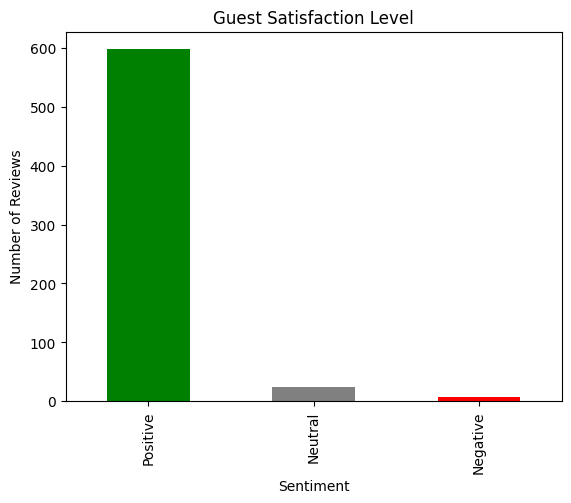

In [9]:
import matplotlib.pyplot as plt

df['sentiment_type'].value_counts().plot(kind='bar', color=['green', 'gray', 'red'])
plt.title('Guest Satisfaction Level')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.savefig('sentiment_chart.png')
plt.show()